# Heart Disease Risk Analysis

## Exploratory data analysis and machine learning classification

This project examines clinical and demographic factors associated with heart disease using the UCI Heart Disease dataset.

### Objectives

- inspect and clean the medical dataset
- explore relationships between patient characteristics and heart disease
- create clear data visualizations
- build and evaluate a classification model
- discuss limitations and responsible use of medical predictions

> This project is for educational and portfolio purposes only. It is not a medical diagnostic tool.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
heart_disease = fetch_ucirepo(id=45)

features = heart_disease.data.features.copy()
target = heart_disease.data.targets.copy()

df = pd.concat([features, target], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
raw_data_path = Path("../data/raw")
raw_data_path.mkdir(parents=True, exist_ok=True)

df.to_csv(
    raw_data_path / "heart_disease_uci.csv",
    index=False
)

print("Dataset shape:", df.shape)
print("Raw dataset saved successfully.")
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (303, 14)
Raw dataset saved successfully.

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [4]:
quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique()
})

display(quality_summary)

print("Duplicated rows:", df.duplicated().sum())
print("\nOriginal target distribution:")
display(df["num"].value_counts().sort_index())

,data_type,missing_values,unique_values
age,int64,0,41
sex,int64,0,2
cp,int64,0,4
trestbps,int64,0,50
chol,int64,0,152
fbs,int64,0,2
restecg,int64,0,3
thalach,int64,0,91
exang,int64,0,2
oldpeak,float64,0,40


Duplicated rows: 0

Original target distribution:


num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [5]:
analysis = df.copy()

analysis = analysis.rename(columns={
    "cp": "chest_pain_type",
    "trestbps": "resting_blood_pressure",
    "chol": "cholesterol",
    "fbs": "fasting_blood_sugar",
    "restecg": "resting_ecg",
    "thalach": "max_heart_rate",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "major_vessels",
    "thal": "thalassemia",
    "num": "disease_severity"
})

# Fill the small number of missing categorical values with the mode
for column in ["major_vessels", "thalassemia"]:
    analysis[column] = analysis[column].fillna(
        analysis[column].mode()[0]
    )

# Create binary classification target:
# 0 = no heart disease, 1 = heart disease present
analysis["heart_disease"] = (
    analysis["disease_severity"] > 0
).astype(int)

analysis["major_vessels"] = analysis["major_vessels"].astype(int)
analysis["thalassemia"] = analysis["thalassemia"].astype(int)

print("Missing values after cleaning:", analysis.isna().sum().sum())
print("Duplicated rows:", analysis.duplicated().sum())
print("\nBinary target distribution:")
display(analysis["heart_disease"].value_counts())

analysis.head()

Missing values after cleaning: 0
Duplicated rows: 0

Binary target distribution:


heart_disease
0    164
1    139
Name: count, dtype: int64

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,major_vessels,thalassemia,disease_severity,heart_disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0,0


In [6]:
processed_data_path = Path("../data/processed")
processed_data_path.mkdir(parents=True, exist_ok=True)

analysis.to_csv(
    processed_data_path / "heart_disease_clean.csv",
    index=False
)

print("Clean dataset saved successfully.")
print("Final dataset shape:", analysis.shape)

Clean dataset saved successfully.
Final dataset shape: (303, 15)


## Exploratory Data Analysis

The analysis compares patients with and without diagnosed heart disease and examines differences in age, maximum heart rate and chest pain type.

In [7]:
disease_labels = {
    0: "No heart disease",
    1: "Heart disease"
}

summary_by_group = (
    analysis
    .groupby("heart_disease")[
        [
            "age",
            "resting_blood_pressure",
            "cholesterol",
            "max_heart_rate",
            "st_depression"
        ]
    ]
    .mean()
    .round(1)
    .rename(index=disease_labels)
)

prevalence = analysis["heart_disease"].mean() * 100

print(f"Heart disease prevalence in the dataset: {prevalence:.1f}%")
display(summary_by_group)

Heart disease prevalence in the dataset: 45.9%


,age,resting_blood_pressure,cholesterol,max_heart_rate,st_depression
heart_disease,,,,,
No heart disease,52.6,129.2,242.6,158.4,0.6
Heart disease,56.6,134.6,251.5,139.3,1.6


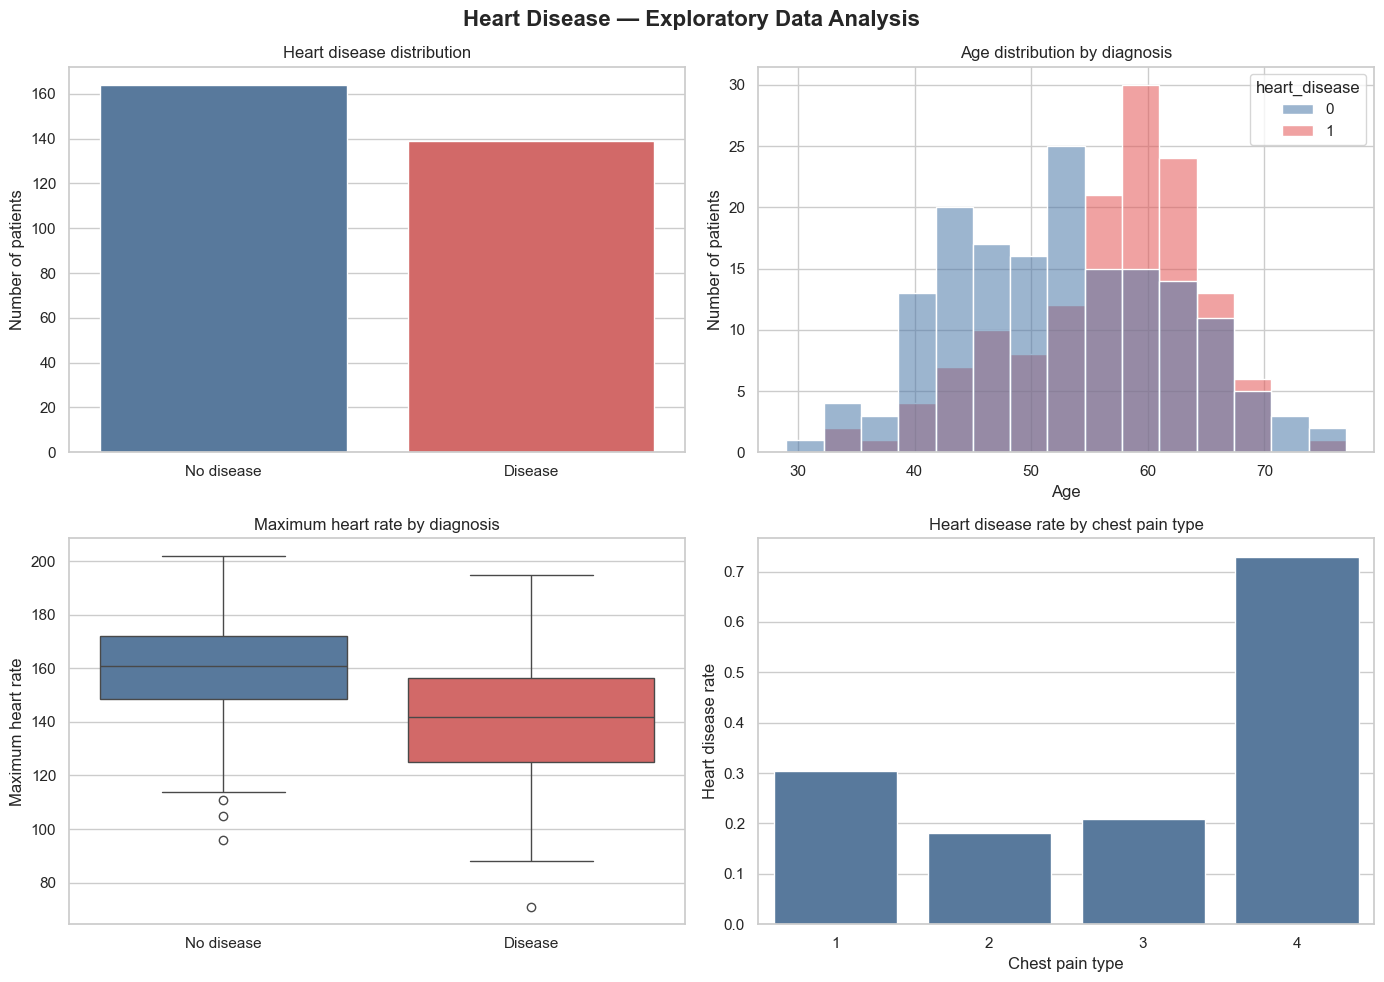

In [8]:
visuals_path = Path("../visuals")
visuals_path.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=analysis,
    x="heart_disease",
    hue="heart_disease",
    palette=["#4C78A8", "#E45756"],
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Heart disease distribution")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Number of patients")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["No disease", "Disease"])

sns.histplot(
    data=analysis,
    x="age",
    hue="heart_disease",
    bins=15,
    multiple="layer",
    palette=["#4C78A8", "#E45756"],
    alpha=0.55,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Age distribution by diagnosis")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Number of patients")

sns.boxplot(
    data=analysis,
    x="heart_disease",
    y="max_heart_rate",
    hue="heart_disease",
    palette=["#4C78A8", "#E45756"],
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Maximum heart rate by diagnosis")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Maximum heart rate")
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["No disease", "Disease"])

sns.barplot(
    data=analysis,
    x="chest_pain_type",
    y="heart_disease",
    color="#4C78A8",
    errorbar=None,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Heart disease rate by chest pain type")
axes[1, 1].set_xlabel("Chest pain type")
axes[1, 1].set_ylabel("Heart disease rate")

plt.suptitle(
    "Heart Disease — Exploratory Data Analysis",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()

plt.savefig(
    visuals_path / "heart_disease_eda_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Machine Learning Model

A logistic regression model is used to classify whether heart disease is present. The data is divided into training and test sets, while preprocessing is performed inside a pipeline to prevent data leakage.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = analysis.drop(
    columns=["disease_severity", "heart_disease"]
)
y = analysis["heart_disease"]

numeric_features = [
    "age",
    "resting_blood_pressure",
    "cholesterol",
    "max_heart_rate",
    "st_depression"
]

categorical_features = [
    column for column in X.columns
    if column not in numeric_features
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("Model trained successfully.")

Training observations: 227
Test observations: 76
Model trained successfully.


In [10]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probability)
    ]
})

model_results["Value"] = model_results["Value"].round(3)

display(model_results)

,Metric,Value
0,Accuracy,0.882
1,Precision,0.882
2,Recall,0.857
3,F1 score,0.870
4,ROC-AUC,0.944


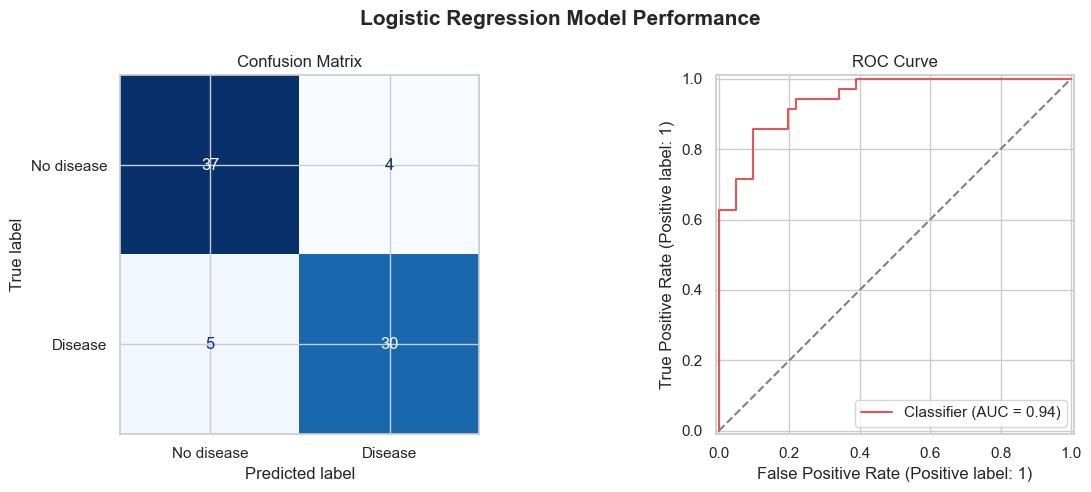

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No disease", "Disease"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    color="#E45756",
    ax=axes[1]
)
axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey"
)
axes[1].set_title("ROC Curve")

plt.suptitle(
    "Logistic Regression Model Performance",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()

plt.savefig(
    visuals_path / "model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Cross-validation

Because the dataset is relatively small, five-fold stratified cross-validation is used to obtain a more reliable estimate of model performance.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_validate(
    model,
    X,
    y,
    cv=cross_validation,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean()
    ],
    "Standard deviation": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std(),
        cv_scores["test_roc_auc"].std()
    ]
}).round(3)

display(cv_results)

,Metric,Mean,Standard deviation
0,Accuracy,0.855,0.060
1,Precision,0.874,0.065
2,Recall,0.798,0.095
3,F1 score,0.832,0.072
4,ROC-AUC,0.916,0.021


In [13]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_table["feature"] = (
    coefficient_table["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

top_features = (
    coefficient_table
    .nlargest(12, "absolute_coefficient")
    .sort_values("coefficient")
)

display(
    top_features[
        ["feature", "coefficient"]
    ].sort_values("coefficient", ascending=False)
)

,feature,coefficient
16,major_vessels_2,1.467074
15,major_vessels_1,1.450702
8,chest_pain_type_4,1.363662
19,thalassemia_7,1.260728
5,sex_1,1.154324
17,major_vessels_3,1.077036
13,st_slope_2,0.637220
11,resting_ecg_2,0.497190
12,exercise_induced_angina_1,0.413336
6,chest_pain_type_2,0.278321


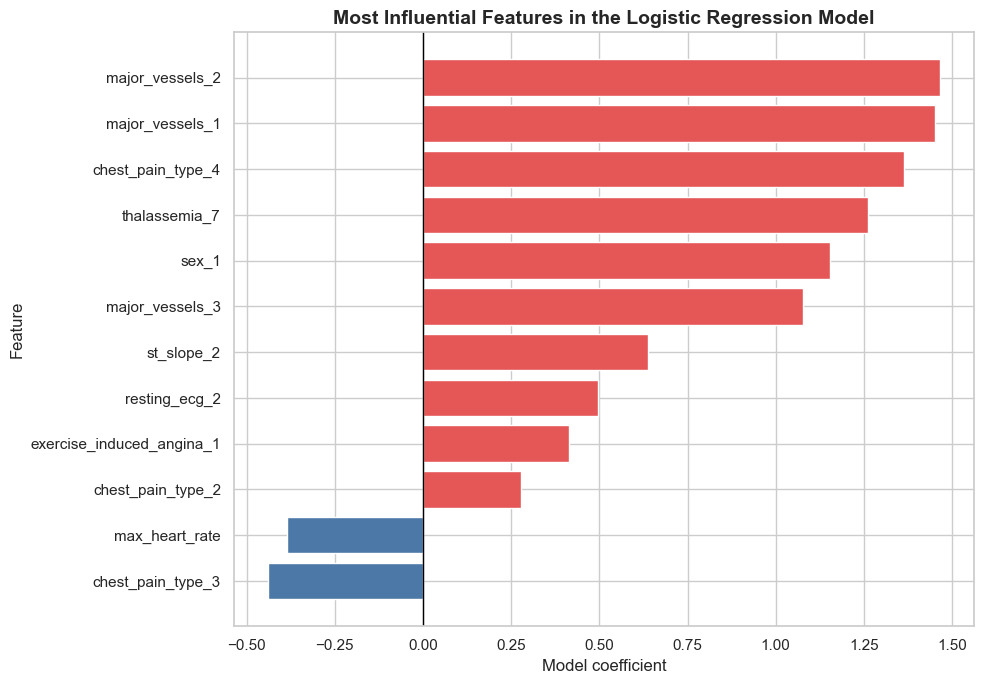

In [14]:
colors = [
    "#4C78A8" if value < 0 else "#E45756"
    for value in top_features["coefficient"]
]

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)
plt.title(
    "Most Influential Features in the Logistic Regression Model",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Model coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    visuals_path / "model_feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## SQL Analysis

The cleaned dataset is stored in a SQLite database. SQL queries are used to calculate population summaries and compare selected patient groups.

In [15]:
import sqlite3

database_path = processed_data_path / "heart_disease.db"

with sqlite3.connect(database_path) as connection:
    analysis.to_sql(
        "heart_disease",
        connection,
        if_exists="replace",
        index=False
    )

print("SQLite database created successfully.")
print("Table name: heart_disease")

SQLite database created successfully.
Table name: heart_disease


In [16]:
sql_query = """
WITH age_groups AS (
    SELECT
        CASE
            WHEN age < 45 THEN 'Under 45'
            WHEN age BETWEEN 45 AND 54 THEN '45–54'
            WHEN age BETWEEN 55 AND 64 THEN '55–64'
            ELSE '65 and older'
        END AS age_group,
        heart_disease
    FROM heart_disease
)

SELECT
    age_group,
    COUNT(*) AS patients,
    SUM(heart_disease) AS patients_with_heart_disease,
    ROUND(
        100.0 * SUM(heart_disease) / COUNT(*),
        1
    ) AS heart_disease_rate_pct
FROM age_groups
GROUP BY age_group
ORDER BY heart_disease_rate_pct DESC;
"""

with sqlite3.connect(database_path) as connection:
    age_group_results = pd.read_sql_query(
        sql_query,
        connection
    )

display(age_group_results)

,age_group,patients,patients_with_heart_disease,heart_disease_rate_pct
0,55–64,119,75,63.0
1,65 and older,41,20,48.8
2,45–54,88,30,34.1
3,Under 45,55,14,25.5


In [17]:
test_metrics = dict(
    zip(
        model_results["Metric"],
        model_results["Value"]
    )
)

cv_metrics = dict(
    zip(
        cv_results["Metric"],
        cv_results["Mean"]
    )
)

print("MODEL SUMMARY")
print("-" * 40)
print(f"Test accuracy: {test_metrics['Accuracy']:.3f}")
print(f"Test recall: {test_metrics['Recall']:.3f}")
print(f"Test ROC-AUC: {test_metrics['ROC-AUC']:.3f}")
print(f"Cross-validated accuracy: {cv_metrics['Accuracy']:.3f}")
print(f"Cross-validated recall: {cv_metrics['Recall']:.3f}")
print(f"Cross-validated ROC-AUC: {cv_metrics['ROC-AUC']:.3f}")

MODEL SUMMARY
----------------------------------------
Test accuracy: 0.882
Test recall: 0.857
Test ROC-AUC: 0.944
Cross-validated accuracy: 0.855
Cross-validated recall: 0.798
Cross-validated ROC-AUC: 0.916


## Conclusions

- The dataset contains 303 patient records, including 164 patients without heart disease and 139 patients with heart disease.
- The exploratory analysis shows measurable differences between the two diagnosis groups across several demographic and clinical variables.
- Logistic regression provides an interpretable baseline classification model.
- Cross-validation was used because the dataset is small and a single train-test split may produce an unstable estimate.
- Recall is especially important in this context because a false-negative prediction represents a patient with heart disease who was classified as not having the condition.
- Model coefficients describe statistical relationships learned from this dataset. They do not establish medical causation.

## Limitations and responsible use

- The dataset is small, historical and primarily based on patients from the Cleveland database.
- Missing values in two variables were replaced with their most frequent values.
- Disease severity was simplified into a binary classification target.
- The model has not been externally validated on patients from other hospitals or populations.
- Performance should be evaluated separately across demographic groups before considering any real-world application.
- This analysis is an educational portfolio project and must not be used for diagnosis or clinical decision-making.